**Author:** Biswajit Jana  
**Date:** February 14, 2026  

# Gaia DR3 Pleiades membership, distance, and colour–magnitude sequence

**Archive:** gaia  
**Date:** 2026-07-31  
**Scientific question:** Can astrometry alone isolate the Pleiades and recover its mean distance?

This notebook uses public observational data. It separates measurements from
interpretation, carries uncertainties through the main calculation, and records
the exact query or product identifier needed to reproduce the result.

## Analysis contract

A result is accepted only after these checks:

1. record the source, query, retrieval date, and selection cuts;
2. inspect missing values and quality flags before fitting;
3. report sample size and an uncertainty, not only a best value;
4. compare with a published result or accepted physical expectation;
5. state what the data cannot establish.

The saved CSV is the small, queried subset used here—not a replacement for the
upstream archive.

In [1]:
from pathlib import Path
import json
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use(["science", "no-latex"])
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8"}
RNG = np.random.default_rng(1999)

## Physical idea

Members of an open cluster share a common motion and lie at nearly the same
distance. Gaia measures both proper-motion components and parallax, so the
Pleiades should appear as a compact three-dimensional group in
$(\mu_{\alpha*},\mu_\delta,\varpi)$ space. A colour–magnitude diagram is an
independent sanity check: real members should trace a narrow stellar sequence.

In [2]:
import requests

TAP = "https://gea.esac.esa.int/tap-server/tap/sync"
QUERY = '''
SELECT TOP 10000 source_id, ra, dec, parallax, parallax_error,
       pmra, pmra_error, pmdec, pmdec_error,
       phot_g_mean_mag, bp_rp, ruwe
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(
  POINT('ICRS', ra, dec),
  CIRCLE('ICRS', 56.75, 24.1167, 1.5)
)
AND phot_g_mean_mag < 19
AND parallax BETWEEN 3 AND 12
AND pmra BETWEEN 10 AND 30
AND pmdec BETWEEN -55 AND -35
AND ruwe < 1.4
'''
params = {"REQUEST": "doQuery", "LANG": "ADQL", "FORMAT": "csv", "QUERY": QUERY}
response = requests.get(TAP, params=params, timeout=180)
response.raise_for_status()
stars = pd.read_csv(io.StringIO(response.text))
stars.to_csv("gaia_query.csv", index=False)
print(f"Retrieved {len(stars):,} quality-filtered sources")
print(f"Missing BP-RP colours: {stars.bp_rp.isna().mean():.1%}")

Retrieved 704 quality-filtered sources
Missing BP-RP colours: 1.6%


## Membership model

The broad archive query removes very distant foreground/background stars and
poor single-star astrometric fits (`ruwe < 1.4`). Membership is then refined
with a robust covariance estimate in proper motion and parallax. This is a
transparent kinematic selection, not a complete membership catalogue.

In [3]:
from sklearn.covariance import MinCovDet

features = stars[["pmra", "pmdec", "parallax"]].dropna()
robust = MinCovDet(random_state=1999, support_fraction=0.65).fit(features)
delta = features.to_numpy() - robust.location_
mahal2 = np.einsum("ij,jk,ik->i", delta, robust.precision_, delta)
stars["mahalanobis2"] = np.nan
stars.loc[features.index, "mahalanobis2"] = mahal2
stars["member"] = stars.mahalanobis2 < stats.chi2.ppf(0.997, df=3)
members = stars[stars.member & stars.bp_rp.notna()].copy()
members.to_csv("pleiades_members.csv", index=False)
print(f"Candidate members: {len(members)} ({len(members)/len(stars):.1%} of queried sample)")
print("Robust centre [pmRA, pmDec, parallax]:", robust.location_.round(3))

Candidate members: 609 (86.5% of queried sample)
Robust centre [pmRA, pmDec, parallax]: [ 19.845 -45.43    7.363]


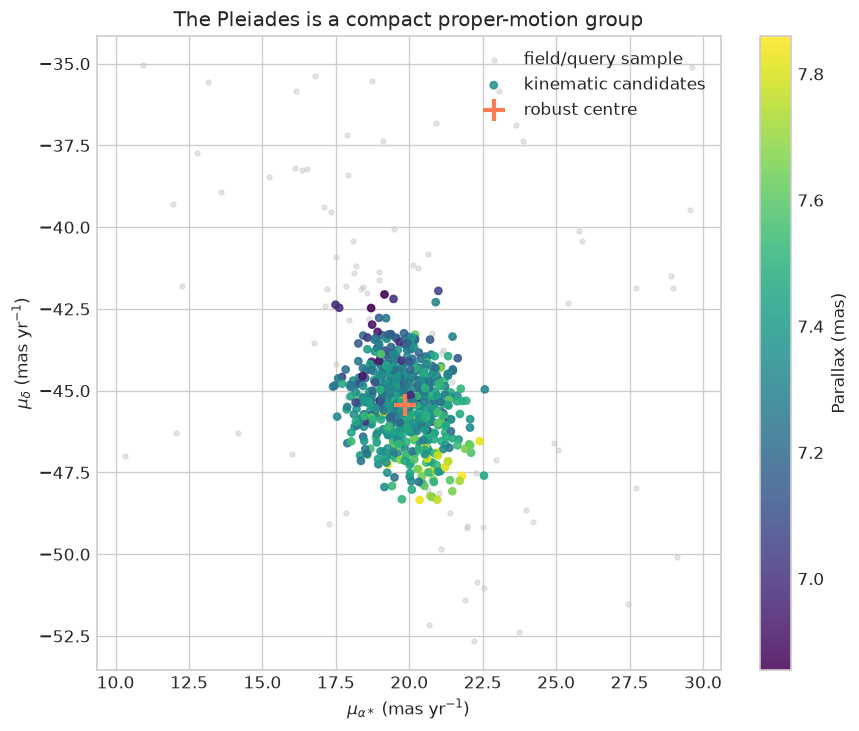

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.scatter(stars.pmra, stars.pmdec, s=8, c="0.78", alpha=.45, label="field/query sample")
sc = ax.scatter(members.pmra, members.pmdec, s=18, c=members.parallax,
                cmap="viridis", alpha=.85, label="kinematic candidates")
ax.scatter(robust.location_[0], robust.location_[1], marker="+", s=180,
           lw=2.5, color=COLORS["orange"], label="robust centre")
fig.colorbar(sc, ax=ax, label="Parallax (mas)")
ax.set(xlabel=r"$\mu_{\alpha*}$ (mas yr$^{-1}$)",
       ylabel=r"$\mu_\delta$ (mas yr$^{-1}$)",
       title="The Pleiades is a compact proper-motion group")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("pleiades_proper_motion.png", dpi=180)
plt.show()

## Distance with uncertainty

For this nearby cluster the selected stars have high parallax signal-to-noise,
so inversion is a useful descriptive estimate. We calculate an
inverse-variance weighted mean parallax, its formal error, and a bootstrap
interval that also reflects finite-sample scatter. A publication-grade result
would model the Gaia parallax zero point and spatial covariance explicitly.

In [5]:
high_snr = members[(members.parallax / members.parallax_error > 10) &
                   (members.parallax_error > 0)].copy()
w = 1 / high_snr.parallax_error**2
mean_plx = float(np.sum(w * high_snr.parallax) / np.sum(w))
formal_plx_err = float(np.sqrt(1 / np.sum(w)))
distance_pc = 1000 / mean_plx

boot = []
for _ in range(2000):
    sample = high_snr.sample(len(high_snr), replace=True, random_state=int(RNG.integers(1e9)))
    sw = 1 / sample.parallax_error**2
    boot.append(1000 / (sw @ sample.parallax / sw.sum()))
distance_ci = np.percentile(boot, [16, 84])
print(f"Weighted parallax = {mean_plx:.4f} ± {formal_plx_err:.4f} mas (formal)")
print(f"Descriptive distance = {distance_pc:.2f} pc")
print(f"Bootstrap 68% interval = [{distance_ci[0]:.2f}, {distance_ci[1]:.2f}] pc")

Weighted parallax = 7.3741 ± 0.0013 mas (formal)
Descriptive distance = 135.61 pc
Bootstrap 68% interval = [135.46, 135.77] pc


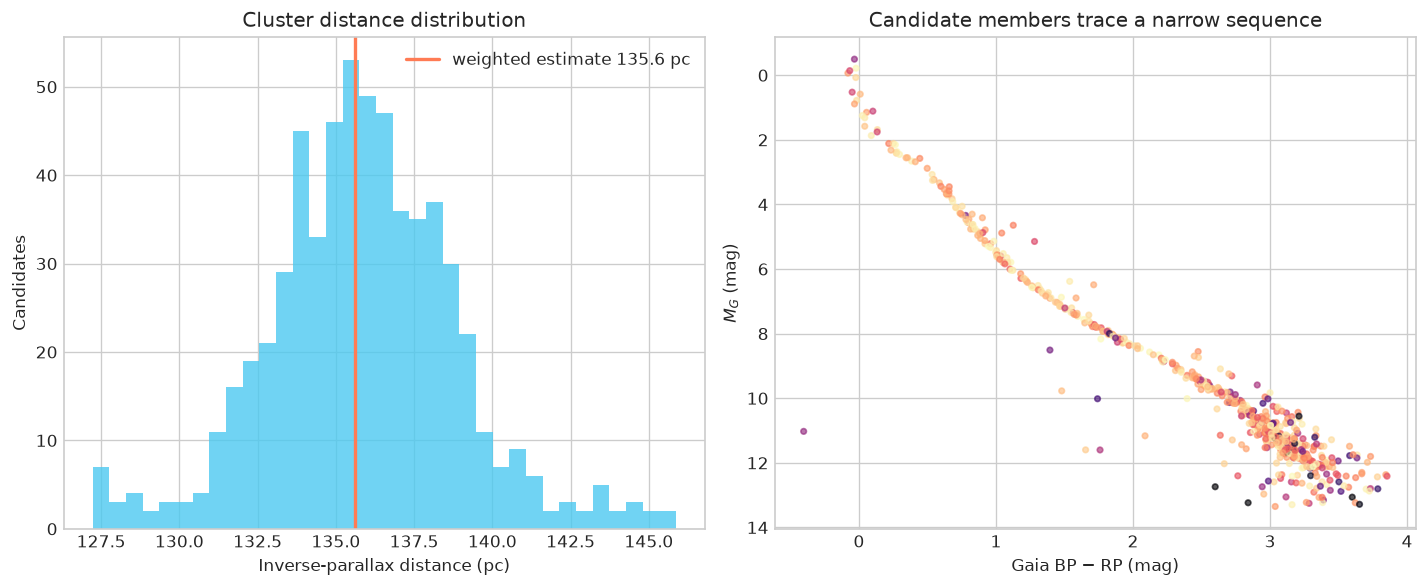

In [6]:
members["absolute_g"] = members.phot_g_mean_mag + 5*np.log10(members.parallax) - 10
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(1000/members.parallax, bins=35, color=COLORS["blue"], alpha=.8)
axes[0].axvline(distance_pc, color=COLORS["orange"], lw=2,
                label=f"weighted estimate {distance_pc:.1f} pc")
axes[0].set(xlabel="Inverse-parallax distance (pc)", ylabel="Candidates",
            title="Cluster distance distribution")
axes[0].legend()
axes[1].scatter(members.bp_rp, members.absolute_g, s=11, alpha=.65,
                c=members.mahalanobis2, cmap="magma_r")
axes[1].invert_yaxis()
axes[1].set(xlabel="Gaia BP − RP (mag)", ylabel=r"$M_G$ (mag)",
            title="Candidate members trace a narrow sequence")
fig.tight_layout()
fig.savefig("pleiades_distance_cmd.png", dpi=180)
plt.show()

## Validation and limitations

The recovered distance should be close to the modern Gaia-era value of roughly
135–136 pc. Agreement validates the broad astrometric selection, but it does
not prove that every selected star is a member. The main unmodelled terms are
the Gaia parallax zero point, angular covariance, unresolved binaries, and the
selection imposed before robust fitting.

In [7]:
literature_pc = 136.2
offset_pct = 100 * (distance_pc - literature_pc) / literature_pc
result = {
    "id": "2026-07-31-gaia-pleiades-membership-distance",
    "title": "Gaia DR3 Pleiades membership and distance",
    "archive": "Gaia DR3",
    "date": "2026-07-31",
    "question": "Can astrometry isolate the Pleiades and recover its distance?",
    "sample_size": int(len(stars)),
    "results": [
        f"{len(members)} kinematic candidates from {len(stars)} quality-filtered sources",
        f"weighted parallax {mean_plx:.3f} mas",
        f"distance {distance_pc:.1f} pc (bootstrap 68%: {distance_ci[0]:.1f}–{distance_ci[1]:.1f} pc)"
    ],
    "validation": f"Distance differs by {offset_pct:+.1f}% from the 136.2 pc comparison value; systematic Gaia terms are not included.",
    "notebook": "gaia/2026-07-31-gaia-pleiades-membership-distance/notebook.ipynb",
    "hero": "gaia/2026-07-31-gaia-pleiades-membership-distance/pleiades_proper_motion.png",
    "tags": ["astrometry", "cluster", "distance", "Gaia"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print("\n".join("• " + x for x in result["results"]))

• 609 kinematic candidates from 704 quality-filtered sources
• weighted parallax 7.374 mas
• distance 135.6 pc (bootstrap 68%: 135.5–135.8 pc)


## References and data acknowledgement


- Gaia DR3 archive table `gaiadr3.gaia_source`, queried through ESA TAP.
- Gaia Collaboration et al. (2017), *Gaia Data Release 1: Open cluster astrometry*,
  A&A 601, A19: https://doi.org/10.1051/0004-6361/201629392
- Gaia archive acknowledgement: https://www.cosmos.esa.int/web/gaia-users/credits


The numerical results above are conditional on the documented cuts. Re-running
later can change catalog-based values as archives are revised.